In [18]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.utils import resample
from pathlib import Path
np.random.seed(42)


In [19]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
INPUT_FILE    = PROJECT_ROOT / "data" / "mlp_data.csv"
RESULTS_FILE  = PROJECT_ROOT / "outputs" / "mlp_results.csv"
LOSS_FILE = PROJECT_ROOT / "outputs" / "mlp_loss.csv"
LOSS_IMAGE = PROJECT_ROOT / "outputs" / "plots" / "mlp_loss.png"

In [20]:
df = pd.read_csv(INPUT_FILE)
df.head()

,zip_code,date,MORTGAGE30US,UNRATE,CPIAUCSL,zhvi_yoy_pct,inventory,days_to_pending,tier_boston_city,tier_inner_suburb,tier_outer_suburb,high_stress,split
0,1826,2021-01-31,-1.315871,0.857990,-0.692296,1.025253,-0.753537,0.652581,0,0,1,0,train
1,2333,2020-04-30,-0.949574,4.929049,-0.975248,-0.543465,-0.159508,0.208728,0,0,1,0,train
2,2459,2018-05-31,-0.128451,-0.402099,-1.198038,-0.164461,0.774547,-0.568015,0,0,1,0,train
3,3053,2020-04-30,-0.949574,4.929049,-0.975248,0.108575,-0.159508,0.208728,0,0,1,0,train
4,2138,2023-12-31,1.301457,-0.402099,1.265793,-1.118338,-1.169087,-0.013199,0,1,0,1,train


In [21]:
# Extract y variable
y = df['high_stress'].values
y = y.reshape(-1, 1)

# Split data into train and test sets
y_train = y[df['split'] == 'train']
y_test = y[df['split'] == 'test']

y[:5], y_train[:5], y_test[:5]

(array([[0],
        [0],
        [0],
        [0],
        [1]]),
 array([[0],
        [0],
        [0],
        [0],
        [1]]),
 array([[0],
        [0],
        [0],
        [0],
        [1]]))

In [22]:
# Extract date features
df['day'] = pd.to_datetime(df['date']).dt.day
df['month'] = pd.to_datetime(df['date']).dt.month
df['year'] = pd.to_datetime(df['date']).dt.year

# One-hot encode zip_code
df = pd.get_dummies(df, columns=['zip_code'])

# Drop unimportant columns
X = df.drop(columns=['high_stress', 'split', 'date'])

X.head()

,MORTGAGE30US,UNRATE,CPIAUCSL,zhvi_yoy_pct,inventory,days_to_pending,tier_boston_city,tier_inner_suburb,tier_outer_suburb,day,...,zip_code_3868,zip_code_3869,zip_code_3870,zip_code_3871,zip_code_3873,zip_code_3874,zip_code_3878,zip_code_3884,zip_code_3885,zip_code_3887
0,-1.315871,0.857990,-0.692296,1.025253,-0.753537,0.652581,0,0,1,31,...,False,False,False,False,False,False,False,False,False,False
1,-0.949574,4.929049,-0.975248,-0.543465,-0.159508,0.208728,0,0,1,30,...,False,False,False,False,False,False,False,False,False,False
2,-0.128451,-0.402099,-1.198038,-0.164461,0.774547,-0.568015,0,0,1,31,...,False,False,False,False,False,False,False,False,False,False
3,-0.949574,4.929049,-0.975248,0.108575,-0.159508,0.208728,0,0,1,30,...,False,False,False,False,False,False,False,False,False,False
4,1.301457,-0.402099,1.265793,-1.118338,-1.169087,-0.013199,0,1,0,31,...,False,False,False,False,False,False,False,False,False,False


In [23]:
X.shape, y.shape

((22245, 284), (22245, 1))

In [24]:
# Split data into train and test sets
X_train = X[df['split'] == 'train']
X_test = X[df['split'] == 'test']

# Min-max scale the features
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Add bias term
X_train = np.concatenate((X_train, np.ones((X_train.shape[0], 1))), axis=1)
X_test = np.concatenate((X_test, np.ones((X_test.shape[0], 1))), axis=1)

X_train, X_test

(array([[0.01033225, 0.26315789, 0.1927176 , ..., 0.        , 0.        ,
         1.        ],
        [0.12601297, 1.        , 0.09488879, ..., 0.        , 0.        ,
         1.        ],
        [0.38533225, 0.03508772, 0.01786056, ..., 0.        , 0.        ,
         1.        ],
        ...,
        [0.72700567, 0.00877193, 0.74739442, ..., 0.        , 0.        ,
         1.        ],
        [1.        , 0.04385965, 0.85435195, ..., 0.        , 0.        ,
         1.        ],
        [0.85767828, 0.06140351, 0.93296779, ..., 0.        , 0.        ,
         1.        ]], shape=(15571, 285)),
 array([[0.        , 0.28947368, 0.18328017, ..., 0.        , 0.        ,
         1.        ],
        [0.07769449, 0.09649123, 0.39650433, ..., 0.        , 0.        ,
         1.        ],
        [0.03038898, 0.30701754, 0.15790789, ..., 0.        , 0.        ,
         1.        ],
        ...,
        [0.78200972, 0.00877193, 0.76798918, ..., 0.        , 0.        ,
         1.   

In [25]:
# See if there is an imbalance in the classess
print(pd.Series(y_train.flatten()).value_counts())

0    11628
1     3943
Name: count, dtype: int64


In [26]:
# Resample training data to balance classes
X_train_df = pd.DataFrame(X_train)
X_train_df['high_stress'] = y_train.flatten()

# Get low_stress and high_stress classes
low_stress = X_train_df[X_train_df['high_stress'] == 0]
high_stress = X_train_df[X_train_df['high_stress'] == 1]

# Downsample low_stress to match high_stress
low_stress_downsampled = resample(low_stress, replace=False, n_samples=len(high_stress), random_state=42)
balanced = pd.concat([low_stress_downsampled, high_stress]).sample(frac=1, random_state=42)

# Extract X and y from balanced data
X_train = balanced.drop(columns='high_stress').values
y_train = balanced['high_stress'].values.reshape(-1, 1)

In [27]:
inp = X_train.shape[1]
q1 = 32
q2 = 16
eta = 0.005

W1 = np.random.randn(inp, q1)
W2 = np.random.randn(q1, q2)
W3 = np.random.randn(q2, 1)

def relu(z):
    return np.maximum(0, z)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def f(x):
    h1 = relu(W1.T.dot(x))
    h2 = relu(W2.T.dot(h1))
    return sigmoid(W3.T.dot(h2))

In [28]:
errors = []
epochs = 600
n = X_train.shape[0]
for epoch in range(epochs):
    dW1, dW2, dW3 = 0, 0, 0
    for i in range(n):
        x = np.reshape(X_train[i], (inp, 1))
        h1 = relu(W1.T.dot(x))
        h2 = relu(W2.T.dot(h1))
        mat1 = np.heaviside(h1, 0)
        mat2 = np.heaviside(h2, 0)
        err = f(x) - y_train[i]
        dW3 += (1/n) * err * h2
        dW2 += (1/n) * err * np.kron(h1, (W3 * mat2).T)
        dW1 += (1/n) * err * np.kron(x, (W2.dot(W3 * mat2) * mat1).T)
    W3 -= eta * dW3
    W2 -= eta * dW2
    W1 -= eta * dW1

    y_preds = f(X_train.T)
    e = (1/n) * np.sum(-y_train * np.log(y_preds) - (1 - y_train) * np.log(1 - y_preds))
    errors.append(e)

In [29]:
y_test_probs= f(X_test.T)
print(y_test_probs)

y_test_pred = (y_test_probs >= 0.5).astype(int)
accuracy = np.mean(y_test_pred.flatten() == y_test.flatten())
print(accuracy)

[[3.50380377e-04 4.94322219e-02 2.55453741e-02 ... 9.06182324e-01
  2.68264298e-02 5.23260021e-01]]
0.8621929298981426


In [30]:
print(classification_report(y_test.flatten(), y_test_pred.flatten()))

              precision    recall  f1-score   support

           0       0.96      0.85      0.90      2470
           1       0.68      0.91      0.77       868

    accuracy                           0.86      3338
   macro avg       0.82      0.88      0.84      3338
weighted avg       0.89      0.86      0.87      3338



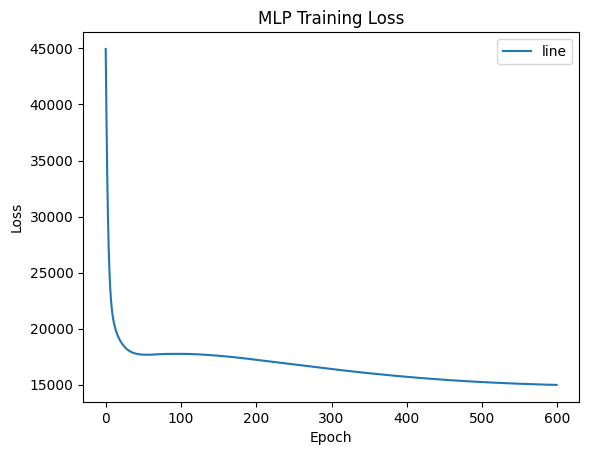

In [31]:
plt.plot(range(epochs), errors, label="line")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.legend()
plt.savefig(LOSS_IMAGE)
plt.show()

In [32]:
print(W1)
print(W2)
print(W3)

[[ 0.52005615 -0.16765203  0.60038219 ... -0.31206076 -0.60294373
   1.98046324]
 [-0.02082223 -1.05895826  0.82858558 ... -0.18443038 -1.10658764
  -1.19908526]
 [ 0.83756277  1.32550931 -0.11683967 ... -0.34600761 -0.39255414
  -1.32816888]
 ...
 [ 0.04721259  0.69346431 -0.43619307 ... -0.33516697 -1.74453289
  -0.68851415]
 [-0.18365694 -0.11495093 -1.48222994 ... -0.40409531  2.03547739
   1.99217554]
 [-0.13586704 -0.61004155  0.6944068  ...  0.7209438  -0.08770934
   1.49485045]]
[[-2.17966132 -1.47973244  0.6821054  -0.04510572  0.65184394  0.06366373
   0.51276668 -0.83168741  0.31769072  1.01673628  1.22282912  2.00933818
   0.25217125  0.25447697 -1.5188956  -0.5109404 ]
 [-0.21533626  1.01656591 -0.61099771  0.78347816  0.02731439 -0.17713915
   0.23192028 -0.39261747 -0.45070176 -1.69629517 -0.24754683 -0.48202324
  -0.51612159  0.40891824  0.67139603  0.23931748]
 [ 0.98786577  0.55051656 -0.29504939 -0.47471393  0.3504981   0.57329281
   1.35349829  1.18207359 -0.6127693

In [33]:
results_df = pd.DataFrame({
    'true_label': y_test.flatten(),
    'pred_prob': y_test_probs.flatten(),
    'pred_label': y_test_pred.flatten()
})
results_df.to_csv(RESULTS_FILE, index=False)

In [34]:
loss_df = pd.DataFrame({'epoch': range(epochs), 'loss': errors})
loss_df.to_csv(LOSS_FILE, index=False)